## Access Station Lucinda Jetty Dalec (Zarr)
This Jupyter notebook demonstrates how to access and plot station_lucinda_jetty_dalec data, available as a [Zarr](https://zarr.dev/) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/4ac6bf81-cd37-4611-8da8-4d5ae5e2bda3).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/station_lucinda_jetty_dalec.ipynb).


In [1]:
dataset_name = "station_lucinda_jetty_dalec"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv
Resolved 155 packages in 685ms
Checked 155 packages in 2ms


✅ Local version 0.3.15 is up to date (remote: 0.3.15)


In [3]:
from DataQuery import GetAodn

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4335: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

In [4]:
# remote zarr dataset
aodn = GetAodn()
dname = f'{dataset_name}.zarr'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 2.29 s, sys: 809 ms, total: 3.1 s
Wall time: 4.83 s


In [5]:
ds = aodn_dataset.zarr_store
ds.info()

xarray.Dataset {
dimensions:
	WAVELENGTH_Ed = 200 ;
	TIME = 3633664 ;
	WAVELENGTH_Lsky = 200 ;
	WAVELENGTH_Lu = 200 ;

variables:
	float64 Ed(WAVELENGTH_Ed, TIME) ;
		Ed:ancillary_variables = LATITUDE LONGITUDE relaz sza pitch pitchsd roll rollsd gearpos Ed_quality_control ;
		Ed:cell_method = LATITUDE: LONGITUDE: TIME: point ;
		Ed:long_name = Surface Downwelling Irradiance in air ;
		Ed:standard_name = surface_downwelling_spectral_radiative_flux_in_air ;
		Ed:units = W m^-2 nm^-1 ;
		Ed:valid_max = 10.0 ;
		Ed:valid_min = 0.0 ;
	int32 Ed_quality_control(WAVELENGTH_Ed, TIME) ;
		Ed_quality_control:flag_meanings = No_QC_was_performed Good_data Probably_good_data Bad_data_that_are_potentially_correctable Bad_data Value_changed Not_used Not_used Not_used Missing_value ;
		Ed_quality_control:flag_values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ;
		Ed_quality_control:long_name = Surface Downwelling Irradiance Quality Control ;
		Ed_quality_control:quality_control_conventions = IMOS standard flags 

## Plot time coverage

In [6]:
aodn_dataset.get_temporal_extent()

(Timestamp('2016-05-26 23:14:33.712716032'),
 Timestamp('2018-12-13 00:11:32.346074112'))

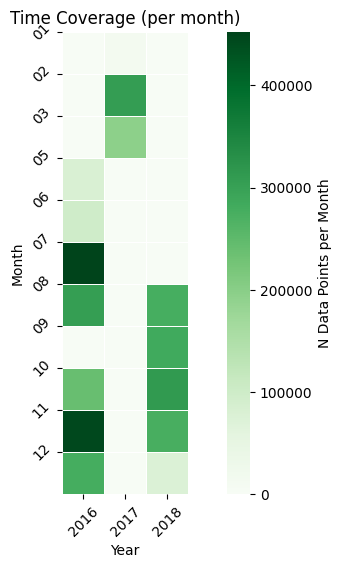

In [7]:
aodn_dataset.plot_time_coverage()

## Load DALEC Radiometry Data

Access the Zarr store containing raw DALEC observations.
DALEC (**D**igital **A**bove-water **L**in**e**ar detector for **C**olour) is a hyperspectral above-water radiometer deployed at Lucinda Jetty on the southern Great Barrier Reef (~18.5°S, 146.4°E). It simultaneously measures:

| Symbol | Variable | Units |
|--------|----------|-------|
| **Ed** | Surface downwelling irradiance | W m⁻² nm⁻¹ |
| **Lsky** | Downwelling sky radiance | W m⁻² nm⁻¹ sr⁻¹ |
| **Lu** | Upwelling radiance from sea surface | W m⁻² nm⁻¹ sr⁻¹ |

These three quantities are used to derive Remote Sensing Reflectance (Rrs) in the derived product dataset.
Each variable has its own wavelength array (`WAVELENGTH_Ed`, `WAVELENGTH_Lsky`, `WAVELENGTH_Lu`).

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

xds = aodn_dataset.zarr_store

time_vals = xds['TIME'].values
t_min = pd.Timestamp(time_vals[0]).strftime('%Y-%m-%d')
t_max = pd.Timestamp(time_vals[-1]).strftime('%Y-%m-%d')

wl_Ed   = xds['WAVELENGTH_Ed'].values
wl_Lsky = xds['WAVELENGTH_Lsky'].values
wl_Lu   = xds['WAVELENGTH_Lu'].values

print(f'Time range  : {t_min}  →  {t_max}  ({len(time_vals):,} observations)')
print(f'Ed   wavelengths : {wl_Ed.min():.1f}–{wl_Ed.max():.1f} nm  ({len(wl_Ed)} bands)')
print(f'Lsky wavelengths : {wl_Lsky.min():.1f}–{wl_Lsky.max():.1f} nm  ({len(wl_Lsky)} bands)')
print(f'Lu   wavelengths : {wl_Lu.min():.1f}–{wl_Lu.max():.1f} nm  ({len(wl_Lu)} bands)')
print()
print(xds['Ed'])

Time range  : 2016-05-26  →  2018-12-13  (3,633,664 observations)
Ed   wavelengths : 399.8–1058.4 nm  (200 bands)
Lsky wavelengths : 400.3–1058.6 nm  (200 bands)
Lu   wavelengths : 397.0–1055.5 nm  (200 bands)

<xarray.DataArray 'Ed' (WAVELENGTH_Ed: 200, TIME: 3633664)> Size: 6GB
dask.array<getitem, shape=(200, 3633664), dtype=float64, chunksize=(200, 1000), chunktype=numpy.ndarray>
Coordinates:
    LATITUDE       float64 8B ...
    LONGITUDE      float64 8B ...
  * TIME           (TIME) datetime64[ns] 29MB 2016-05-26T23:14:33.712716032 ....
  * WAVELENGTH_Ed  (WAVELENGTH_Ed) float32 800B 399.8 403.2 ... 1.058e+03
Attributes:
    ancillary_variables:  LATITUDE LONGITUDE relaz sza pitch pitchsd roll rol...
    cell_method:          LATITUDE: LONGITUDE: TIME: point
    long_name:            Surface Downwelling Irradiance in air
    standard_name:        surface_downwelling_spectral_radiative_flux_in_air
    units:                W m^-2 nm^-1
    valid_max:            10.0
    valid_min: 

## Radiometric Spectral Signatures

Ed, Lsky, and Lu spectra at selected dates (daily median). These three quantities
are the fundamental inputs to remote sensing reflectance retrieval:

> **Rrs(λ) = (Lu(λ) − ρ · Lsky(λ)) / Ed(λ)**

A typical mid-latitude coastal spectrum shows maximum Ed around 550–600 nm
(solar irradiance peak), Lsky decreasing monotonically from UV to NIR,
and Lu shaped by the optical properties of the water column.

*Note: DALEC wavelength grids may differ slightly between Ed, Lsky and Lu sensors.*

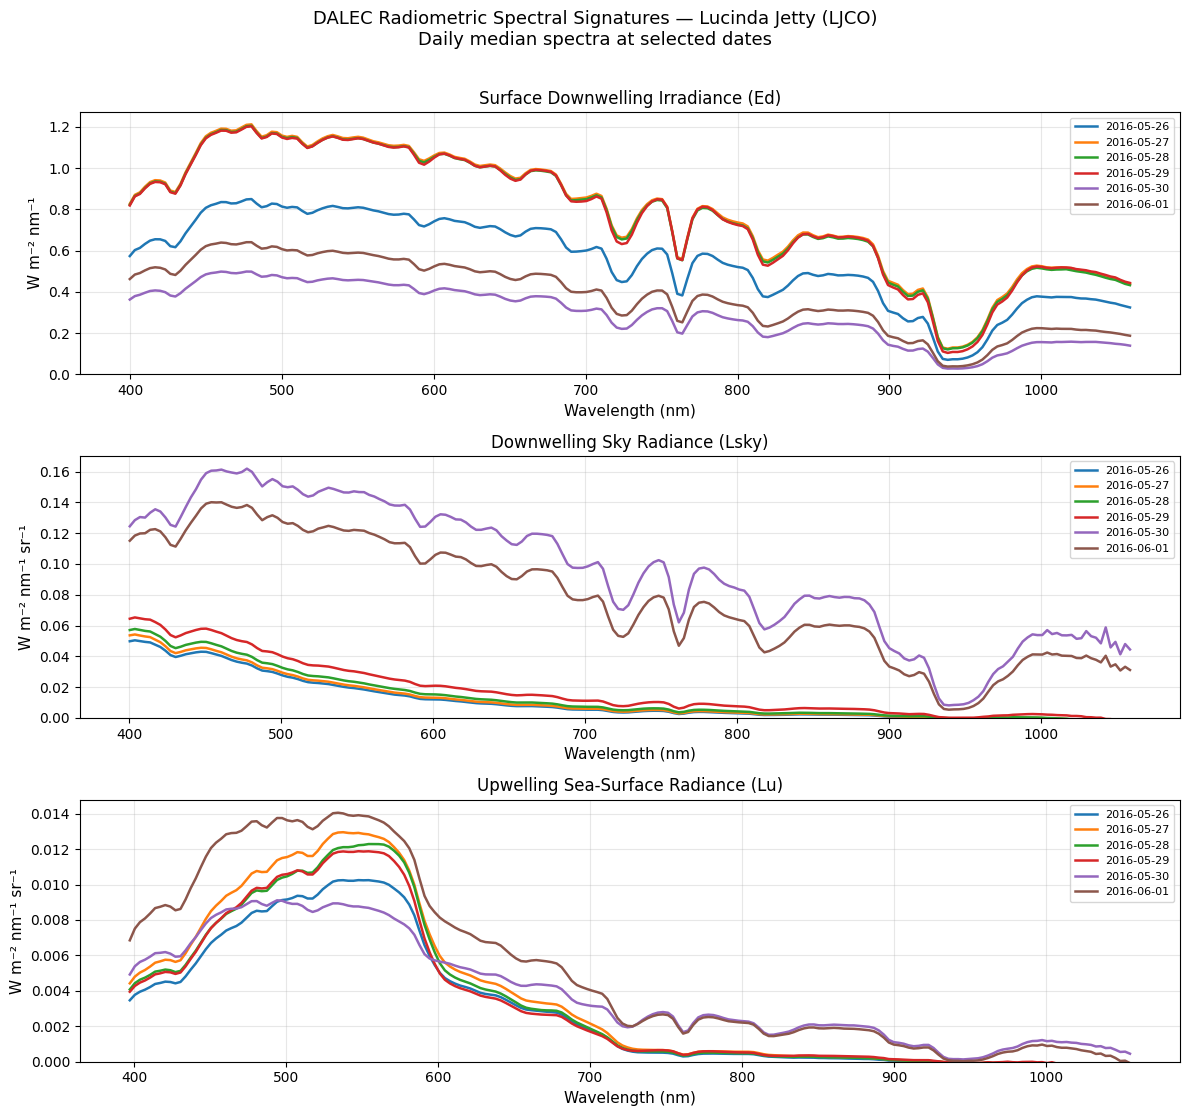

In [9]:
DATE_START = '2016-05-01'
DATE_END   = '2016-06-01'
time_vals = xds['TIME'].values
DATE_START = DATE_START or pd.Timestamp(time_vals[0]).strftime('%Y-%m-%d')
DATE_END   = DATE_END   or pd.Timestamp(time_vals[-1]).strftime('%Y-%m-%d')

wl_Ed   = xds['WAVELENGTH_Ed'].values
wl_Lsky = xds['WAVELENGTH_Lsky'].values
wl_Lu   = xds['WAVELENGTH_Lu'].values

# Daily median for each variable
Ed_daily   = xds['Ed'].sel(TIME=slice(DATE_START, DATE_END)).resample(TIME='1D').median('TIME').astype(float)
Lsky_daily = xds['Lsky'].sel(TIME=slice(DATE_START, DATE_END)).resample(TIME='1D').median('TIME').astype(float)
Lu_daily   = xds['Lu'].sel(TIME=slice(DATE_START, DATE_END)).resample(TIME='1D').median('TIME').astype(float)

# Pick 6 evenly-spaced dates with valid Ed data
good_times = Ed_daily.TIME.values[
    np.where(~np.all(np.isnan(Ed_daily.values), axis=0))[0]
]
n_show = min(6, len(good_times))
pick_idx = np.linspace(0, len(good_times) - 1, n_show, dtype=int)
sample_times = good_times[pick_idx]

cmap = plt.get_cmap('tab10')
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=False)

specs = [
    (axes[0], Ed_daily,   wl_Ed,   'Ed',   'W m⁻² nm⁻¹',     'Surface Downwelling Irradiance (Ed)'),
    (axes[1], Lsky_daily, wl_Lsky, 'Lsky', 'W m⁻² nm⁻¹ sr⁻¹', 'Downwelling Sky Radiance (Lsky)'),
    (axes[2], Lu_daily,   wl_Lu,   'Lu',   'W m⁻² nm⁻¹ sr⁻¹', 'Upwelling Sea-Surface Radiance (Lu)'),
]

for ax, da, wl, vname, units, title in specs:
    for i, t in enumerate(sample_times):
        spec  = da.sel(TIME=t, method='nearest').values
        label = pd.Timestamp(t).strftime('%Y-%m-%d')
        ax.plot(wl, spec, color=cmap(i), lw=1.8, label=label)
    ax.set_xlabel('Wavelength (nm)', fontsize=11)
    ax.set_ylabel(units, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

fig.suptitle(
    'DALEC Radiometric Spectral Signatures — Lucinda Jetty (LJCO)\n'
    'Daily median spectra at selected dates',
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

## Ed Hovmöller Diagram

Wavelength–time heatmap of daily-median downwelling irradiance (Ed).
The seasonal envelope reflects the solar cycle: higher irradiance during
austral summer (DJF), lower in winter (JJA).
Gaps indicate cloudy days or periods with no valid QC-passed measurements.

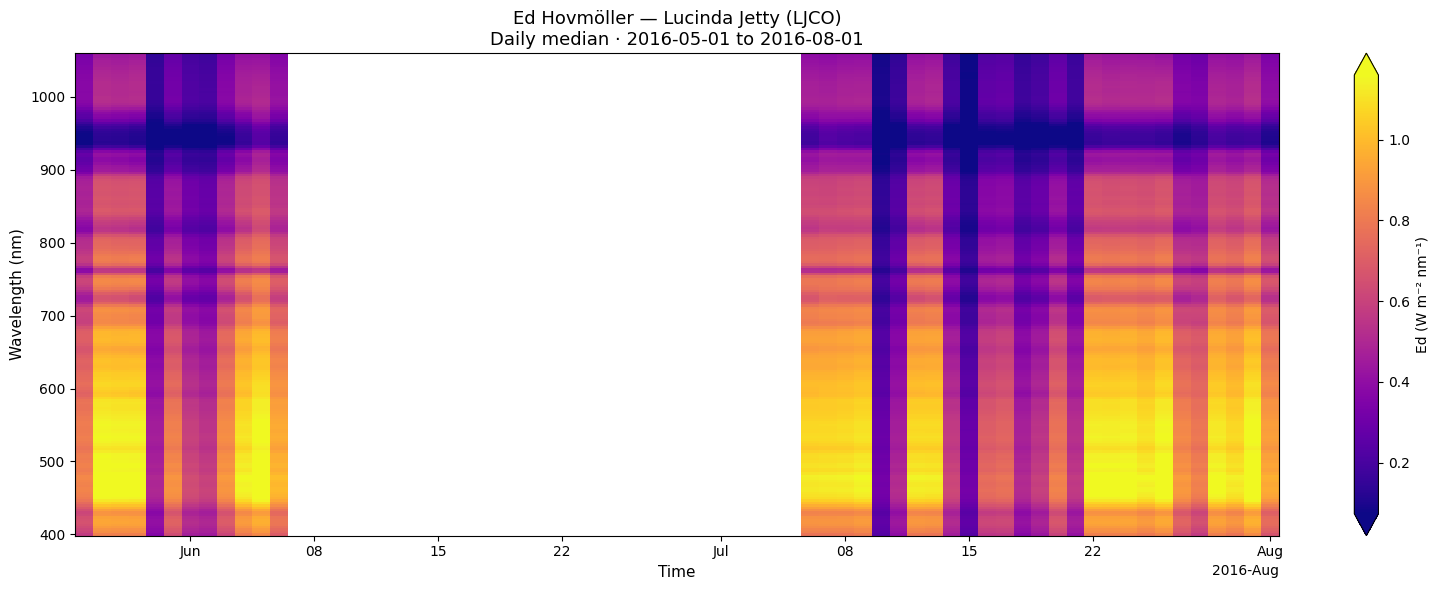

In [10]:
DATE_START = '2016-05-01'
DATE_END   = '2016-08-01'
time_vals = xds['TIME'].values
DATE_START = DATE_START or pd.Timestamp(time_vals[0]).strftime('%Y-%m-%d')
DATE_END   = DATE_END   or pd.Timestamp(time_vals[-1]).strftime('%Y-%m-%d')

wl_Ed = xds['WAVELENGTH_Ed'].values
Ed_daily = (
    xds['Ed']
    .sel(TIME=slice(DATE_START, DATE_END))
    .resample(TIME='1D').median('TIME')
    .astype(float)
)

fig, ax = plt.subplots(figsize=(16, 6))
Ed_daily.plot(
    x='TIME', y='WAVELENGTH_Ed',
    ax=ax, robust=True,
    cmap='plasma',
    cbar_kwargs={'label': 'Ed (W m⁻² nm⁻¹)'},
)
ax.set_title(
    'Ed Hovmöller — Lucinda Jetty (LJCO)\n'
    f'Daily median · {DATE_START} to {DATE_END}',
    fontsize=13,
)
ax.set_xlabel('Time', fontsize=11)
ax.set_ylabel('Wavelength (nm)', fontsize=11)
plt.tight_layout()
plt.show()

## Lu Hovmöller Diagram

Wavelength–time heatmap of daily-median upwelling radiance (Lu).
Lu encodes the optical signal leaving the water column and is the primary
ocean-colour information source. The spectral shape shifts seasonally:
- **Green-dominated (DJF wet season)**: sediment resuspension and CDOM loading from river runoff
- **Blue-shifted (JJA dry season)**: clearer water with reduced scattering

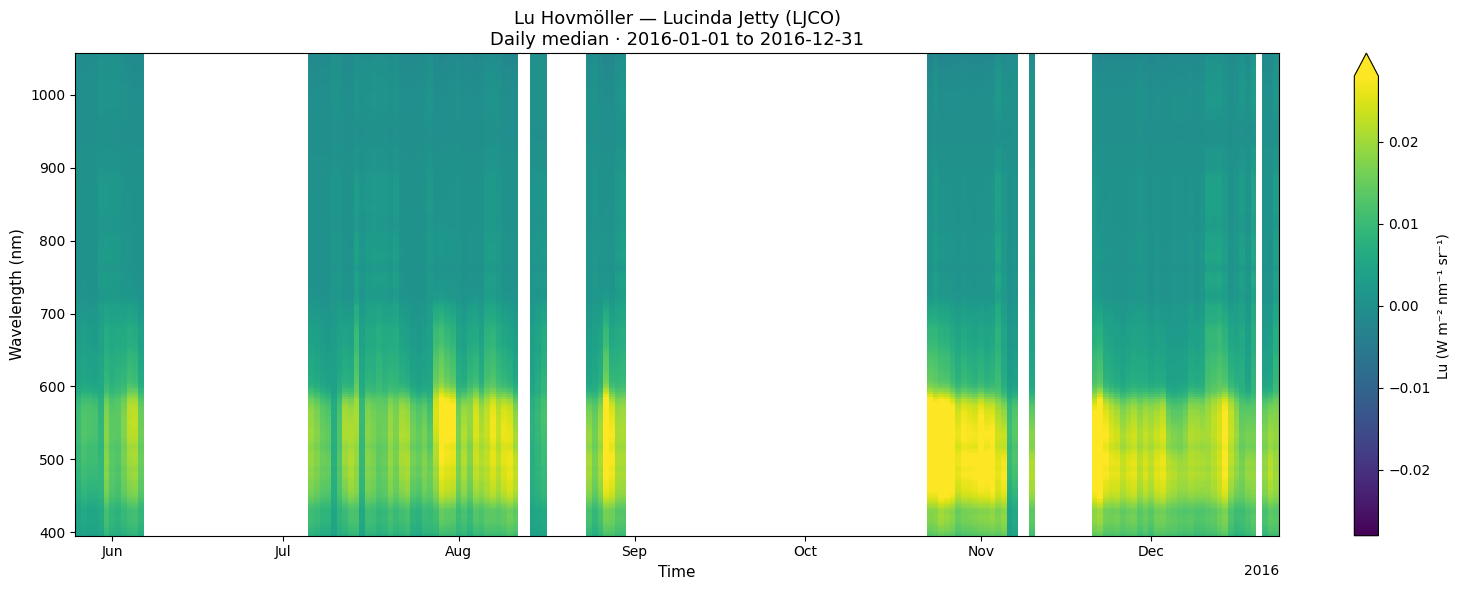

In [11]:
DATE_START = '2016-01-01'
DATE_END   = '2016-12-31'
time_vals = xds['TIME'].values
DATE_START = DATE_START or pd.Timestamp(time_vals[0]).strftime('%Y-%m-%d')
DATE_END   = DATE_END   or pd.Timestamp(time_vals[-1]).strftime('%Y-%m-%d')

Lu_daily = (
    xds['Lu']
    .sel(TIME=slice(DATE_START, DATE_END))
    .resample(TIME='1D').median('TIME')
    .astype(float)
)

fig, ax = plt.subplots(figsize=(16, 6))
Lu_daily.plot(
    x='TIME', y='WAVELENGTH_Lu',
    ax=ax, robust=True,
    cmap='viridis',
    cbar_kwargs={'label': 'Lu (W m⁻² nm⁻¹ sr⁻¹)'},
)
ax.set_title(
    'Lu Hovmöller — Lucinda Jetty (LJCO)\n'
    f'Daily median · {DATE_START} to {DATE_END}',
    fontsize=13,
)
ax.set_xlabel('Time', fontsize=11)
ax.set_ylabel('Wavelength (nm)', fontsize=11)
plt.tight_layout()
plt.show()

## Measurement Geometry

DALEC records the illumination and viewing geometry for every observation.
Good-quality ocean-colour retrievals require:
- **Solar zenith angle (sza)**: < 70° (preferably 20–60°) to avoid excessive Fresnel reflectance
- **Relative solar azimuth (relaz)**: near 135° (sun behind sensor, minimising sun glint)
- **Gear position (gearpos)**: sensor deployment angle

These geometry flags are used in the QC procedure to screen out observations
collected under adverse illumination or viewing conditions.

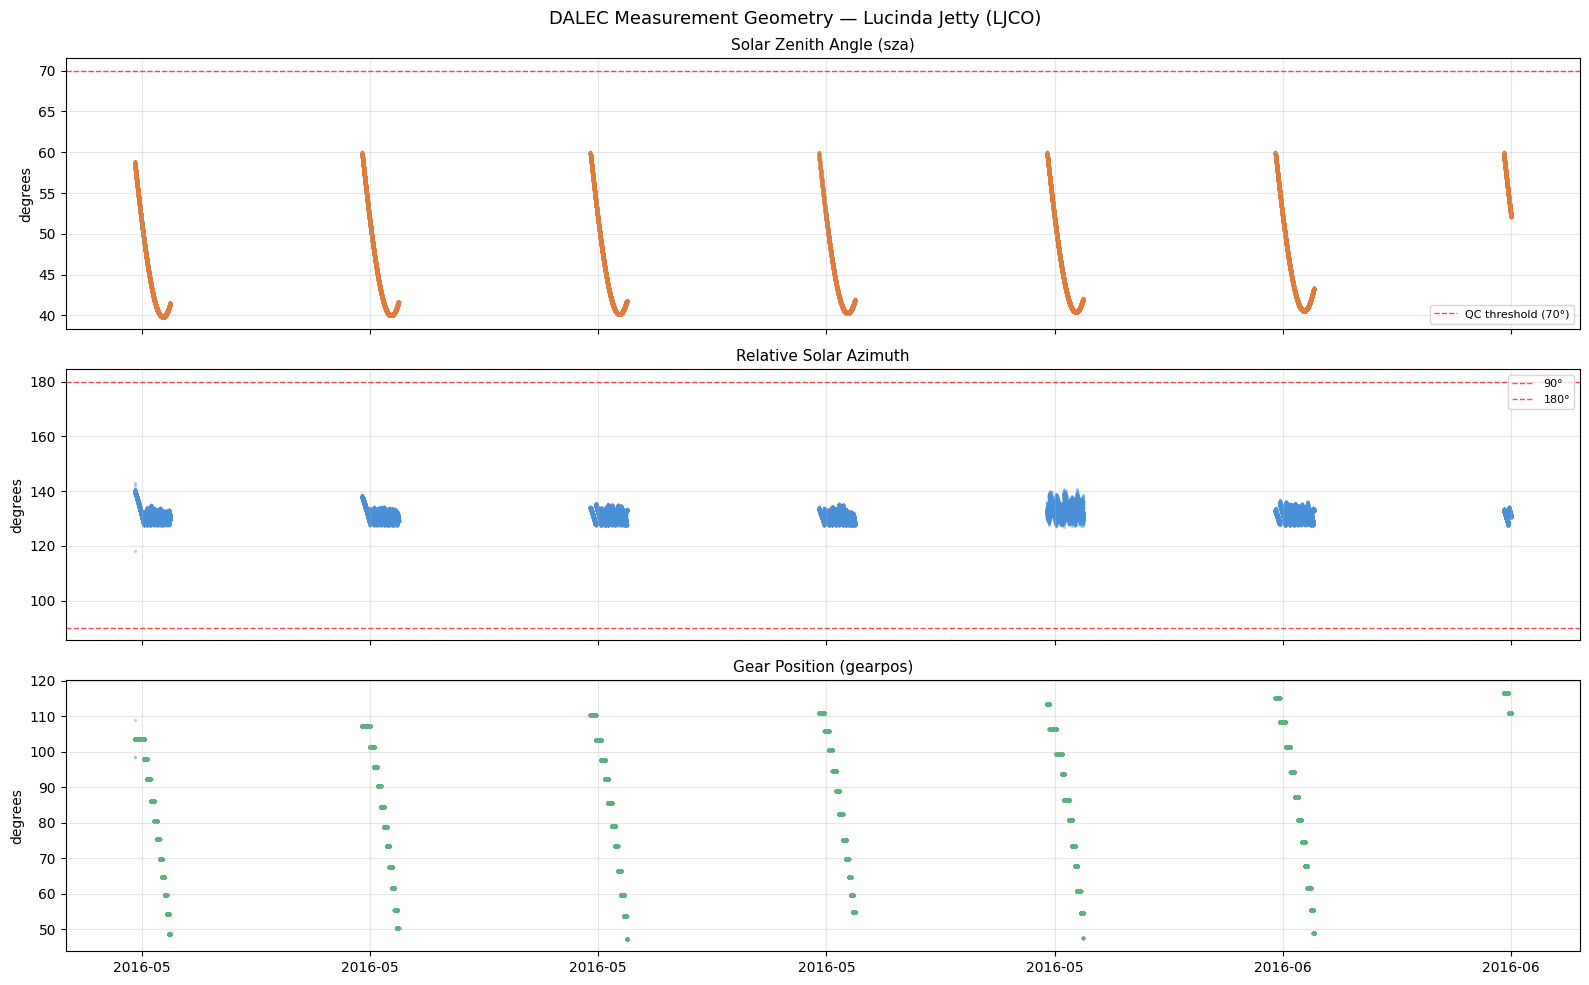

In [12]:
DATE_START = '2016-05-01'
DATE_END   = '2016-06-01'
time_vals = xds['TIME'].values
DATE_START = DATE_START or pd.Timestamp(time_vals[0]).strftime('%Y-%m-%d')
DATE_END   = DATE_END   or pd.Timestamp(time_vals[-1]).strftime('%Y-%m-%d')

t_slice = slice(DATE_START, DATE_END)
t_pd = pd.to_datetime(xds['TIME'].sel(TIME=t_slice).values)

sza_vals    = xds['sza'].sel(TIME=t_slice).values.astype(float)
relaz_vals  = xds['relaz'].sel(TIME=t_slice).values.astype(float)
gearpos_vals = xds['gearpos'].sel(TIME=t_slice).values.astype(float)

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

geom_data = [
    (axes[0], sza_vals,    'Solar Zenith Angle (sza)',   'degrees', '#e07b39', [70], ['QC threshold (70°)']),
    (axes[1], relaz_vals,  'Relative Solar Azimuth',     'degrees', '#4a90d9', [90, 180], ['90°', '180°']),
    (axes[2], gearpos_vals,'Gear Position (gearpos)',    'degrees', '#5ab27e', [], []),
]

for ax, vals, title, units, color, hlines, hlabels in geom_data:
    valid = ~np.isnan(vals)
    ax.scatter(t_pd[valid], vals[valid], s=2, alpha=0.3, color=color)
    for hv, hl in zip(hlines, hlabels):
        ax.axhline(hv, color='red', lw=1, ls='--', alpha=0.7, label=hl)
    ax.set_ylabel(units, fontsize=10)
    ax.set_title(title, fontsize=11)
    if hlines:
        ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.suptitle(
    'DALEC Measurement Geometry — Lucinda Jetty (LJCO)',
    fontsize=13,
)
plt.tight_layout()
plt.show()

## Data Quality Summary

Fraction of observations passing IMOS quality control (QC flag = 1 "Good data")
for each of the three radiometric variables, binned by month.

High QC-pass rates indicate stable conditions (clear skies, optimal sun geometry).
Low rates in winter may reflect limited daylight windows and overcast conditions.

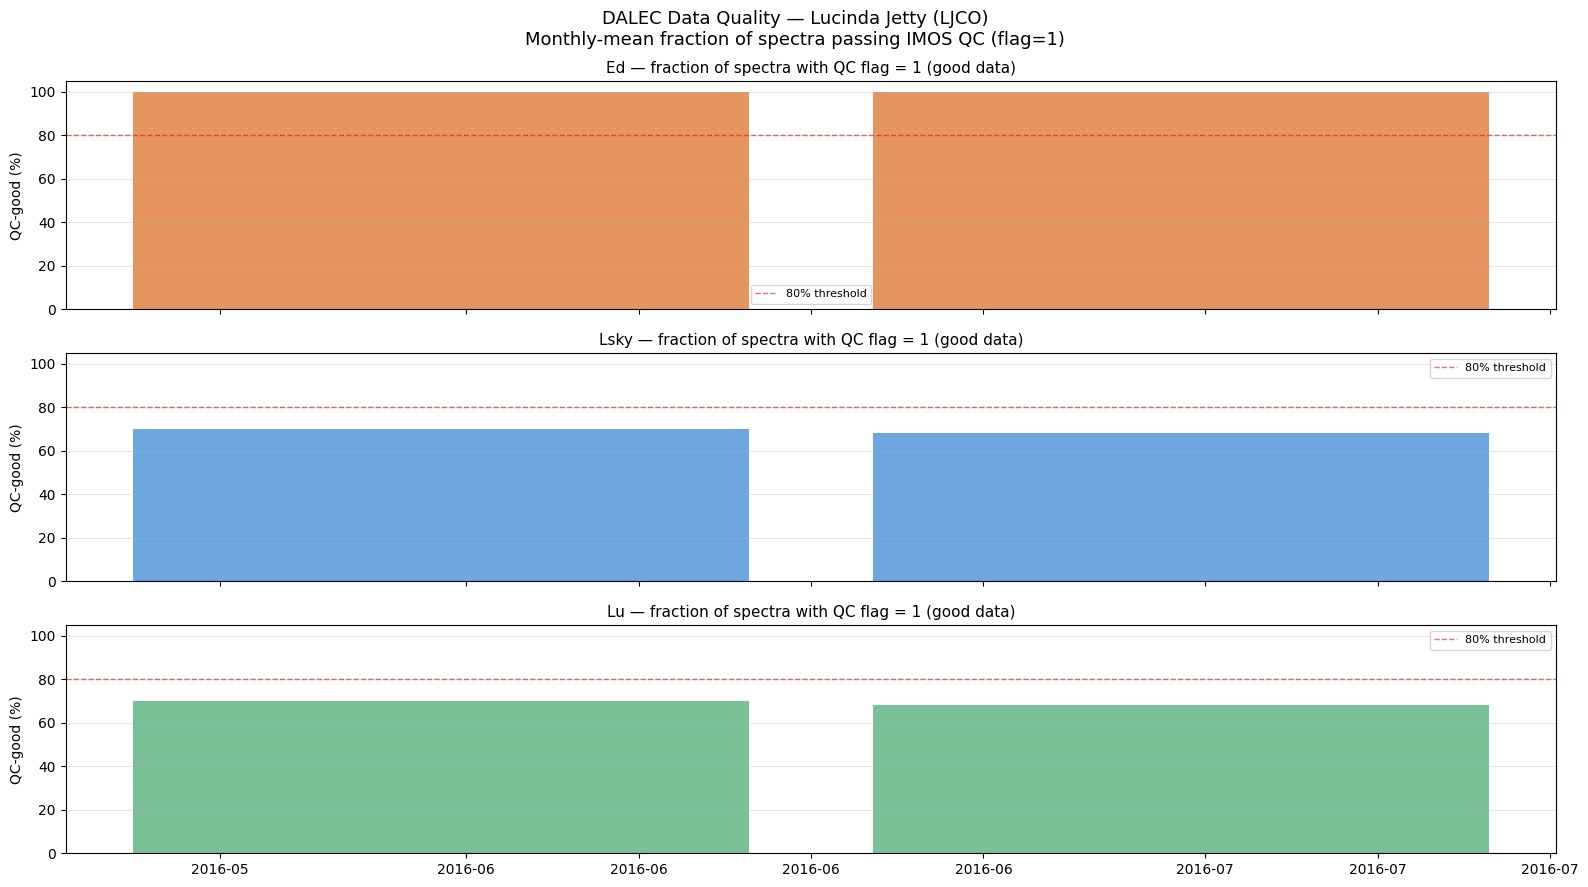

In [13]:
DATE_START = '2016-05-01'
DATE_END   = '2016-06-01'
time_vals = xds['TIME'].values
DATE_START = DATE_START or pd.Timestamp(time_vals[0]).strftime('%Y-%m-%d')
DATE_END   = DATE_END   or pd.Timestamp(time_vals[-1]).strftime('%Y-%m-%d')

t_slice = slice(DATE_START, DATE_END)

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

qc_vars = [
    ('Ed_quality_control',   'Ed',   '#e07b39'),
    ('Lsky_quality_control', 'Lsky', '#4a90d9'),
    ('Lu_quality_control',   'Lu',   '#5ab27e'),
]

for ax, (qc_var, label, color) in zip(axes, qc_vars):
    qc = xds[qc_var].sel(TIME=t_slice)  # shape (WAVELENGTH_X, TIME)
    # Fraction of QC=1 across wavelength dimension for each time step
    frac_good = (qc == 1).mean(dim=qc.dims[0]).values.astype(float)
    t_pd = pd.to_datetime(qc['TIME'].values)
    # Monthly mean
    df = pd.Series(frac_good, index=t_pd).resample('ME').mean()
    ax.bar(df.index, df.values * 100, width=25, color=color, alpha=0.8, align='center')
    ax.set_ylabel('QC-good (%)', fontsize=10)
    ax.set_title(f'{label} — fraction of spectra with QC flag = 1 (good data)', fontsize=11)
    ax.set_ylim(0, 105)
    ax.axhline(80, color='red', lw=1, ls='--', alpha=0.6, label='80% threshold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.suptitle(
    'DALEC Data Quality — Lucinda Jetty (LJCO)\n'
    'Monthly-mean fraction of spectra passing IMOS QC (flag=1)',
    fontsize=13,
)
plt.tight_layout()
plt.show()